<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

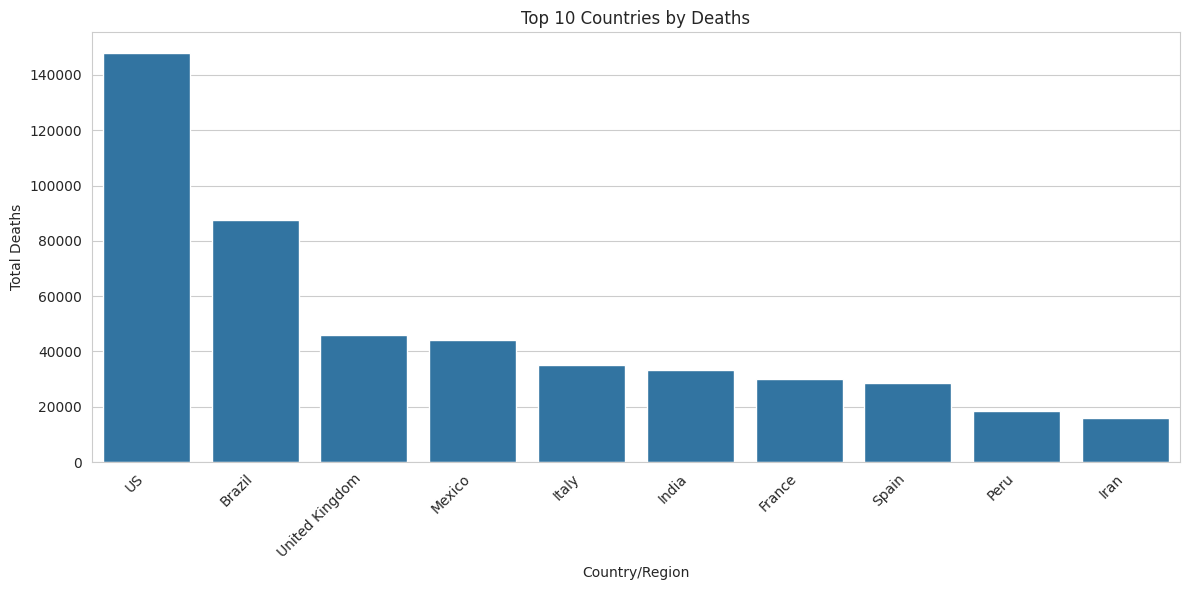

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("whitegrid")
df= pd.read_csv("country_wise_latest.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()
mean_deaths =df['Deaths'].mean()
print(f"The mean number of deaths is: {mean_deaths}")
country_deaths =df.groupby('Country/Region')['Deaths'].sum().sort_values(ascending=False)
top_10_countries = country_deaths.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values)
plt.title('Top 10 Countries by Deaths')
plt.xlabel('Country/Region')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_770/1725509948.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')


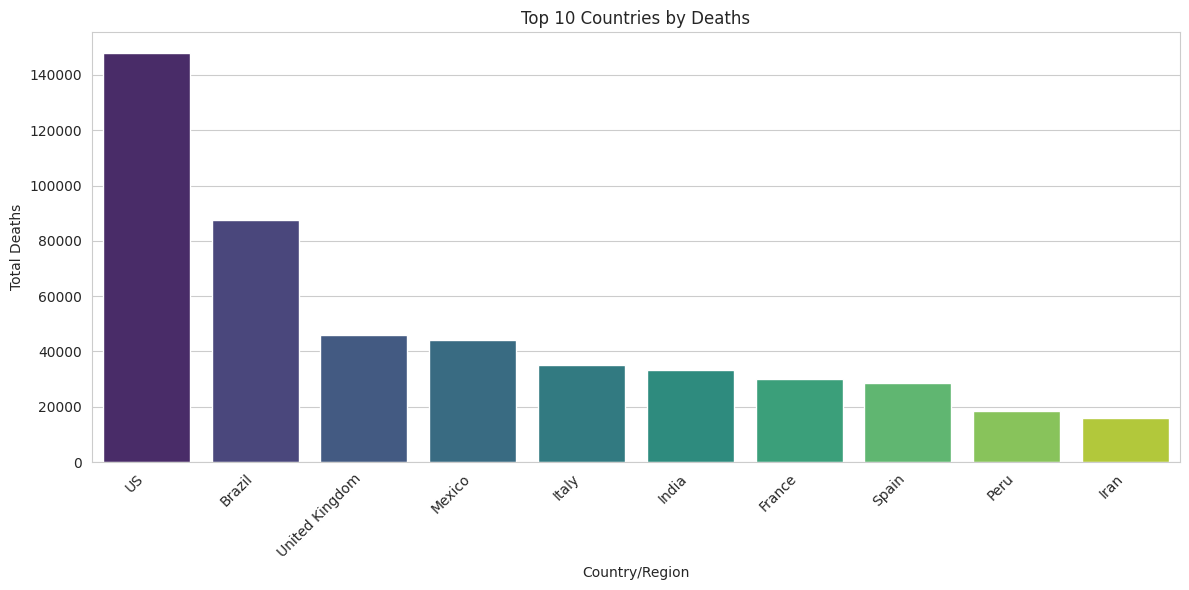

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Country/Region and sum the deaths
country_deaths = df.groupby('Country/Region')['Deaths'].sum().sort_values(ascending=False)

# Select the top 10 countries for better readability
top_10_countries = country_deaths.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.title('Top 10 Countries by Deaths')
plt.xlabel('Country/Region')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45, ha='right') # Rotate country names for better visibility
plt.tight_layout()
plt.show()

In [ ]:
mean_deaths = df['Deaths'].mean()
print(f"The mean number of deaths is: {mean_deaths}")

# Task
Perform a comprehensive exploratory data analysis of the `country_wise_latest.csv` dataset. This involves: analyzing the distributions of 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases; calculating and visualizing the correlation matrix of numerical columns; analyzing total cases by 'WHO Region'; identifying and visualizing the top 10 countries for 'Confirmed', 'Recovered', and 'Active' cases; examining weekly changes in cases; and analyzing 'Deaths / 100 Cases' and 'Recovered / 100 Cases' rates. Finally, summarize all key findings from the analysis.

## Initial Data Overview

### Subtask:
Review the basic statistics, data types, and missing values of the dataset. This includes reconfirming the data loaded, its structure, and the mean number of deaths calculated previously.


### Initial Data Overview Summary

The review of the dataset has been completed based on the outputs from the previous code execution. Here's a summary:

1.  **`df.info()` Output Review:**
    *   The DataFrame `df` contains 187 entries and 15 columns.
    *   Columns include a mix of `object` (Country/Region, WHO Region), `int64` (Confirmed, Deaths, Recovered, Active, New cases, New deaths, New recovered, Confirmed last week, 1 week change), and `float64` (Deaths / 100 Cases, Recovered / 100 Cases, Deaths / 100 Recovered, 1 week % increase) data types.
    *   All columns show 187 non-null counts, indicating no missing values in the dataset.

2.  **`df.describe()` Output Review:**
    *   This output provides a comprehensive statistical summary for numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values. For example, the average number of `Confirmed` cases is around 88,130, and the average `Deaths` is about 3,497.

3.  **`df.isnull().sum()` Output Review:**
    *   As inferred from `df.info()`, this command explicitly confirms that there are no missing values (`NaN`) in any of the columns, as all counts for `isnull().sum()` are zero.

4.  **`df.head()` Output Review:**
    *   The first few rows of the DataFrame (`df.head()`) were displayed, confirming that the data was loaded correctly and provides a snapshot of the dataset structure and content.

5.  **Mean Number of Deaths:**
    *   The calculated mean number of deaths, `mean_deaths`, was reconfirmed as approximately **3497.52**, which aligns with the output from the previous cell.

## Distribution Analysis of Key Metrics

### Subtask:
Visualize the distributions of key numerical columns such as 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases using histograms or box plots to understand their spread and identify potential outliers.


**Reasoning**:
To visualize the distributions of 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases, I will create histograms for each, using a logarithmic scale on the x-axis due to the expected skewed nature of the data. This will involve creating subplots and ensuring proper labels and titles for readability.



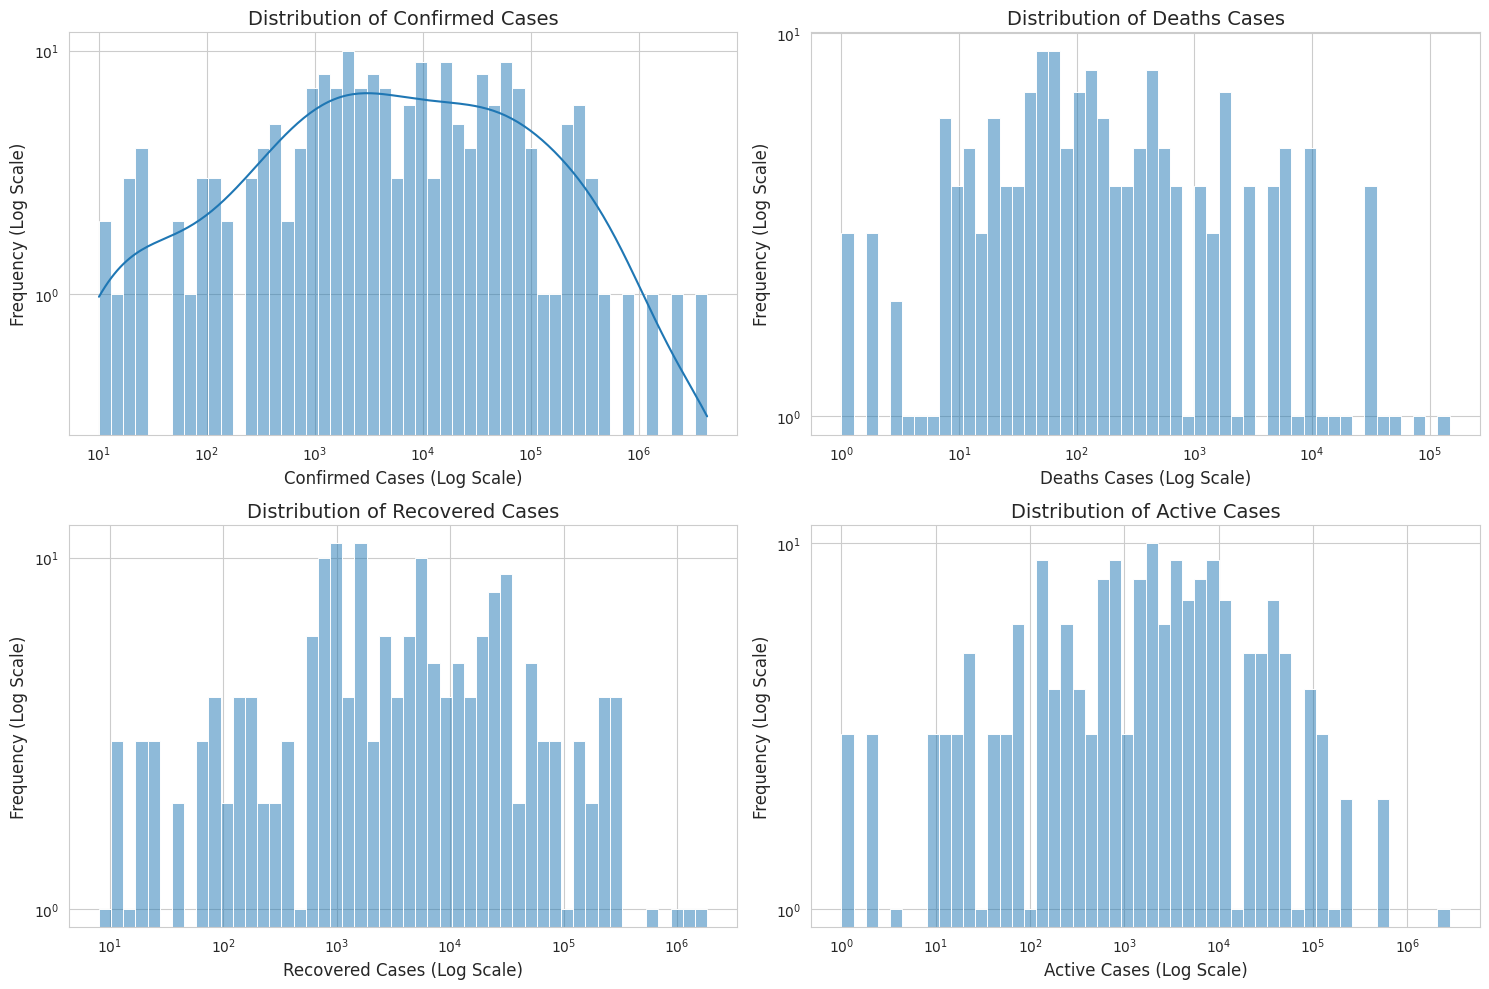

Histograms for 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases have been generated with logarithmic scales on both axes to better visualize their distributions.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the columns to visualize
columns_to_plot = ['Confirmed', 'Deaths', 'Recovered', 'Active']

# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

# Loop through each column and create a histogram
for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col], ax=axes[i], bins=50, kde=True, log_scale=(True, False))
    axes[i].set_title(f'Distribution of {col} Cases', fontsize=14)
    axes[i].set_xlabel(f'{col} Cases (Log Scale)', fontsize=12)
    axes[i].set_ylabel('Frequency (Log Scale)', fontsize=12)
    axes[i].set_yscale('log') # Set y-axis to log scale as well to better visualize frequencies

plt.tight_layout()
plt.show()

print("Histograms for 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases have been generated with logarithmic scales on both axes to better visualize their distributions.")

## Correlation Analysis

### Subtask:
Calculate and visualize the correlation matrix for all relevant numerical columns to identify relationships between different metrics like confirmed cases, deaths, and recoveries. A heatmap will be used for visualization.


**Reasoning**:
To analyze the relationships between different numerical metrics, I will calculate the correlation matrix of all relevant numerical columns and visualize it using a heatmap with annotations for clarity.



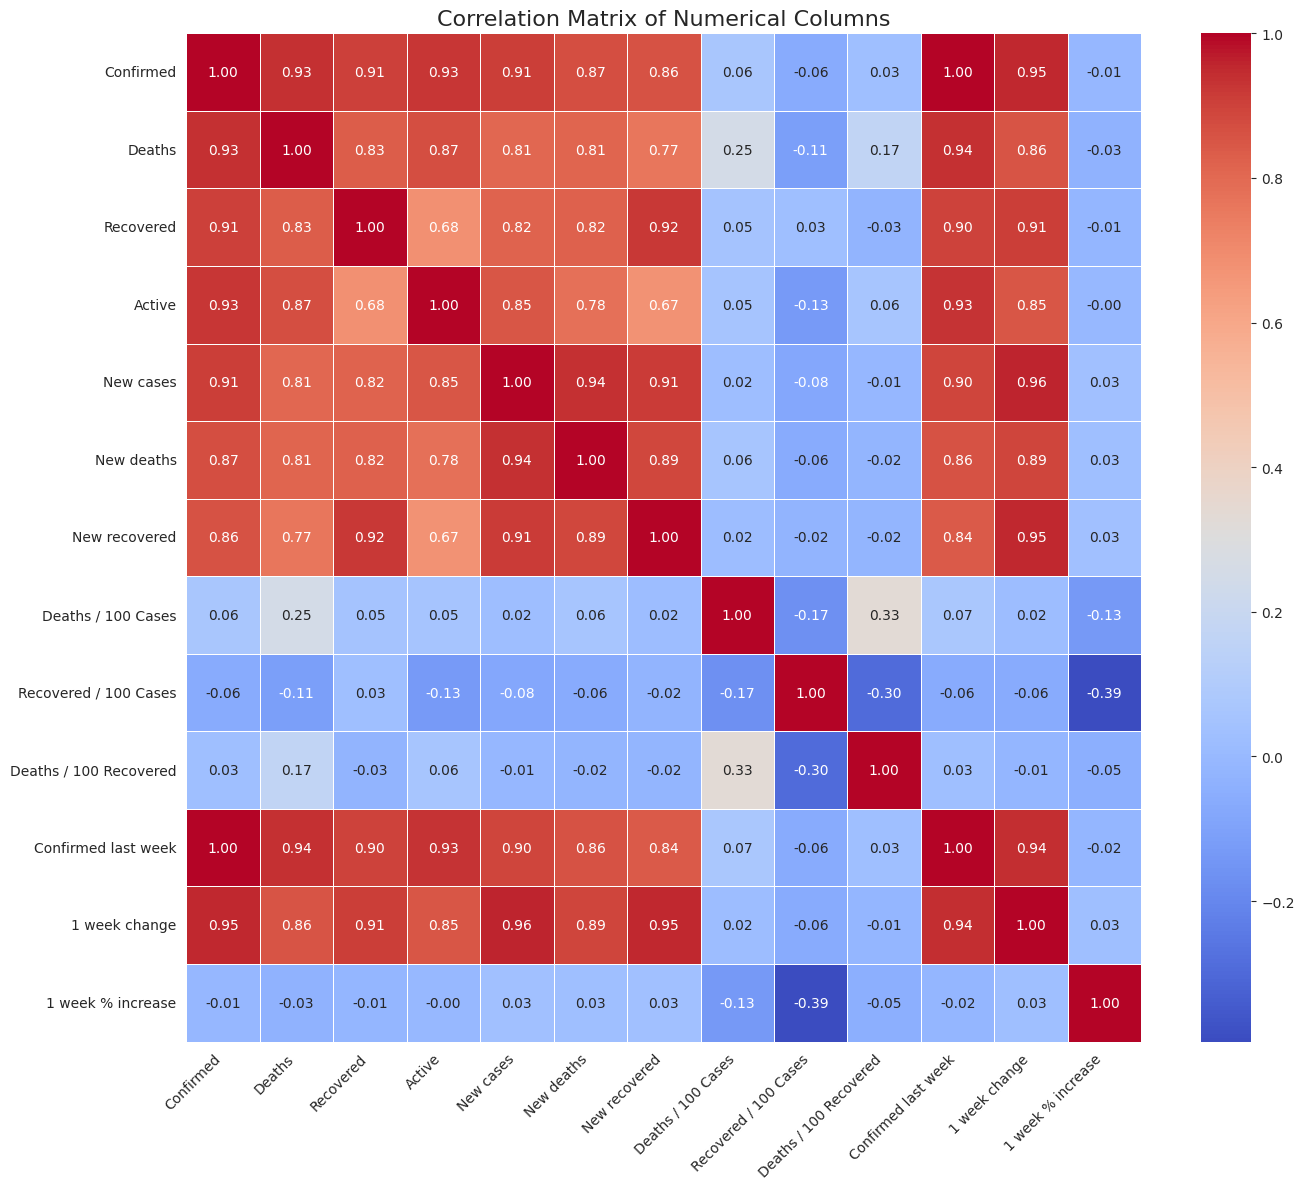

Correlation matrix heatmap displayed successfully, showing relationships between numerical variables.


In [11]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Correlation matrix heatmap displayed successfully, showing relationships between numerical variables.")

## WHO Region Analysis

### Subtask:
Group the data by 'WHO Region' and analyze the total 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases for each region. This will provide insights into regional impact.


**Reasoning**:
To analyze the total 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases by 'WHO Region', I will group the DataFrame by this column and sum the specified case types. Then, I will print the resulting DataFrame to show the aggregated data.



In [12]:
cases_columns = ['Confirmed', 'Deaths', 'Recovered', 'Active']
regional_cases = df.groupby('WHO Region')[cases_columns].sum().sort_values(by='Confirmed', ascending=False)

print("Total Confirmed, Deaths, Recovered, and Active cases by WHO Region:")
print(regional_cases)

Total Confirmed, Deaths, Recovered, and Active cases by WHO Region:
                       Confirmed  Deaths  Recovered   Active
WHO Region                                                  
Americas                 8839286  342732    4468616  4027938
Europe                   3299523  211144    1993723  1094656
South-East Asia          1835297   41349    1156933   637015
Eastern Mediterranean    1490744   38339    1201400   251005
Africa                    723207   12223     440645   270339
Western Pacific           292428    8249     206770    77409


**Reasoning**:
To visualize the regional impact, I will create bar plots for 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases by 'WHO Region' as per the instructions. This involves setting up a figure with subplots and iterating through the case types to generate individual bar charts.



/tmp/ipykernel_770/3114911692.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_cases.index, y=regional_cases[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_770/3114911692.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(regional_cases.index, rotation=45, ha='right') # Rotate x-axis labels for readability
/tmp/ipykernel_770/3114911692.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_cases.index, y=regional_cases[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_770/3114911692.py:17: UserWarning: set_ticklabels() should only be used with a fixed

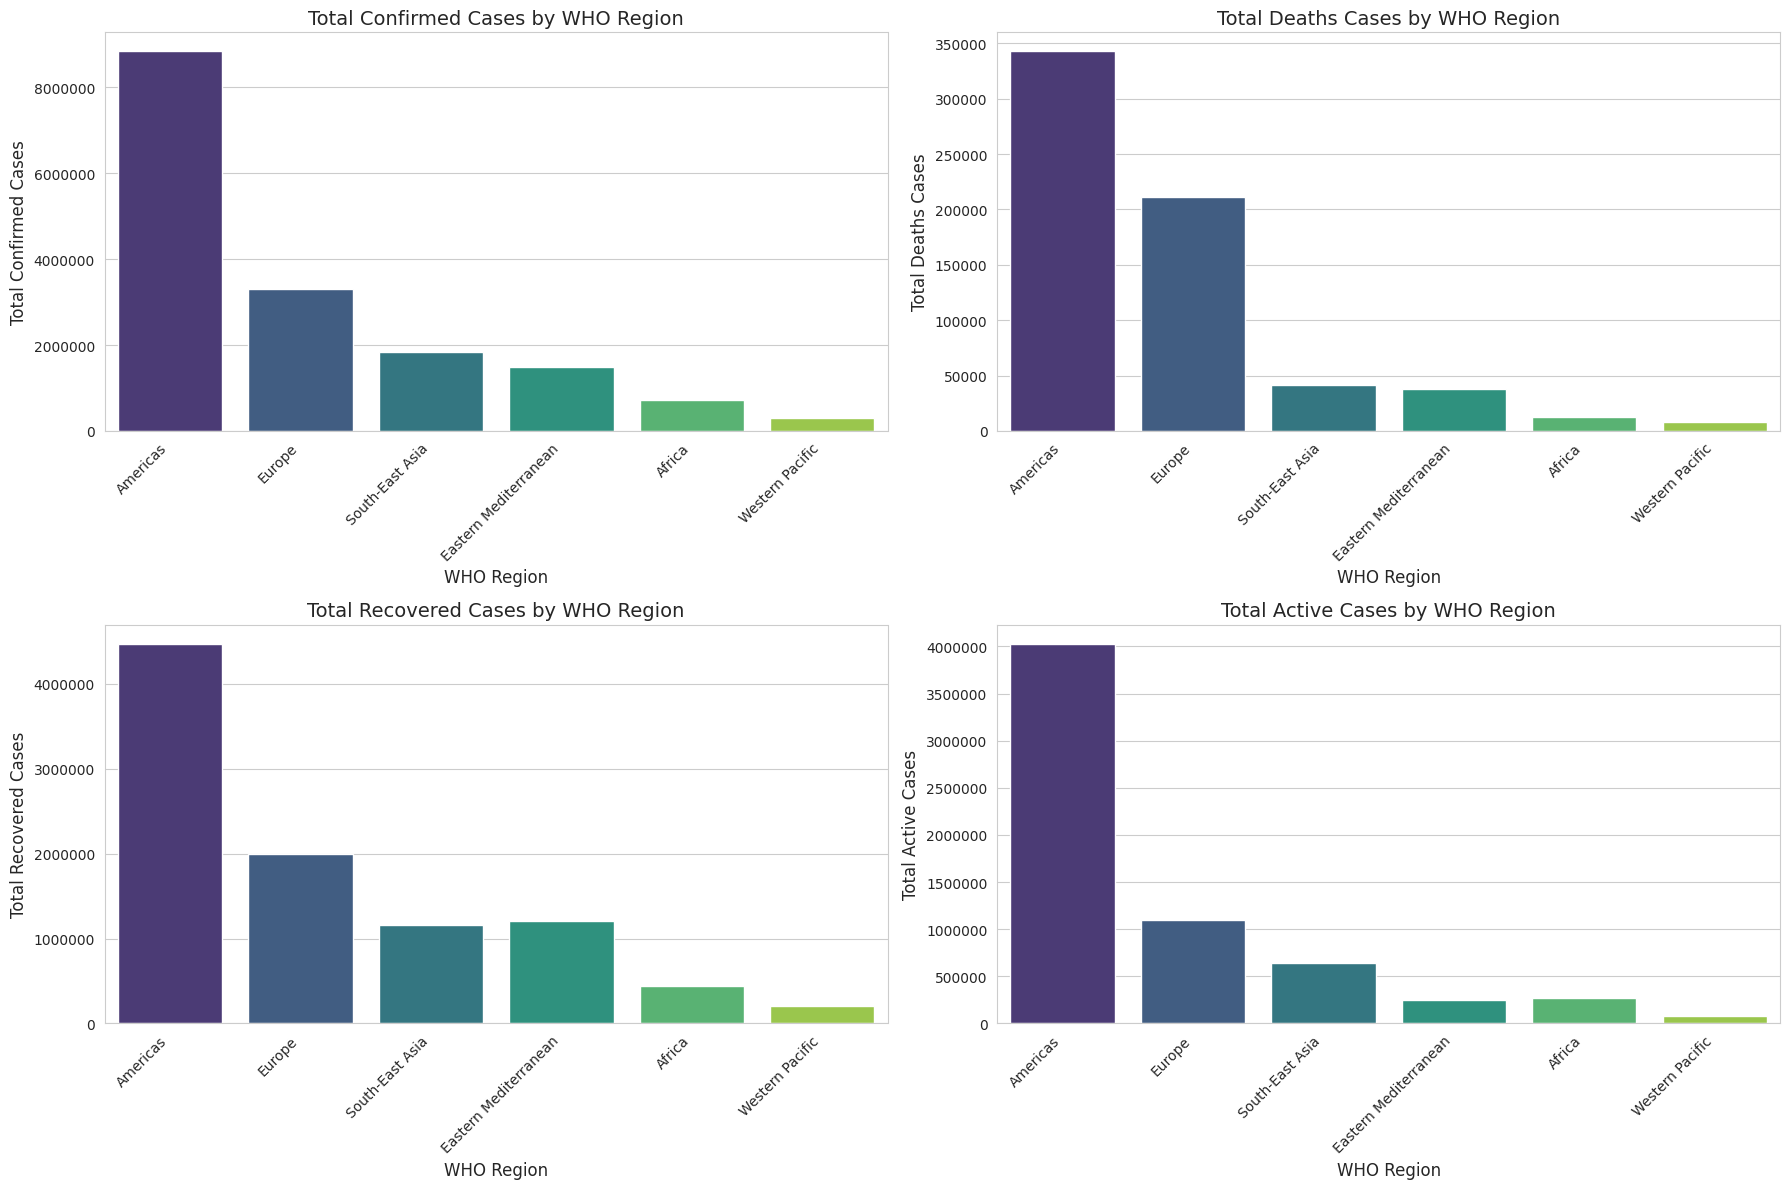

Bar plots for total 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases by WHO Region have been generated.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cases_columns = ['Confirmed', 'Deaths', 'Recovered', 'Active']

# Create a figure and a set of subplots for the bar plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

# Loop through each case type and create a bar plot
for i, col in enumerate(cases_columns):
    sns.barplot(x=regional_cases.index, y=regional_cases[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Total {col} Cases by WHO Region', fontsize=14)
    axes[i].set_xlabel('WHO Region', fontsize=12)
    axes[i].set_ylabel(f'Total {col} Cases', fontsize=12)
    axes[i].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
    axes[i].set_xticklabels(regional_cases.index, rotation=45, ha='right') # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()

print("Bar plots for total 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases by WHO Region have been generated.")

**Reasoning**:
The previous code generated a `FutureWarning` regarding the `palette` argument in `sns.barplot` and a `UserWarning` about `set_xticklabels`. To address the `FutureWarning`, I will assign the `x` variable to `hue` and set `legend=False` as suggested. For the `UserWarning`, ensuring that `set_xticklabels` is applied after the axes have established their ticks is important. By explicitly setting the x-tick labels after the plot is drawn, it should resolve the warning.



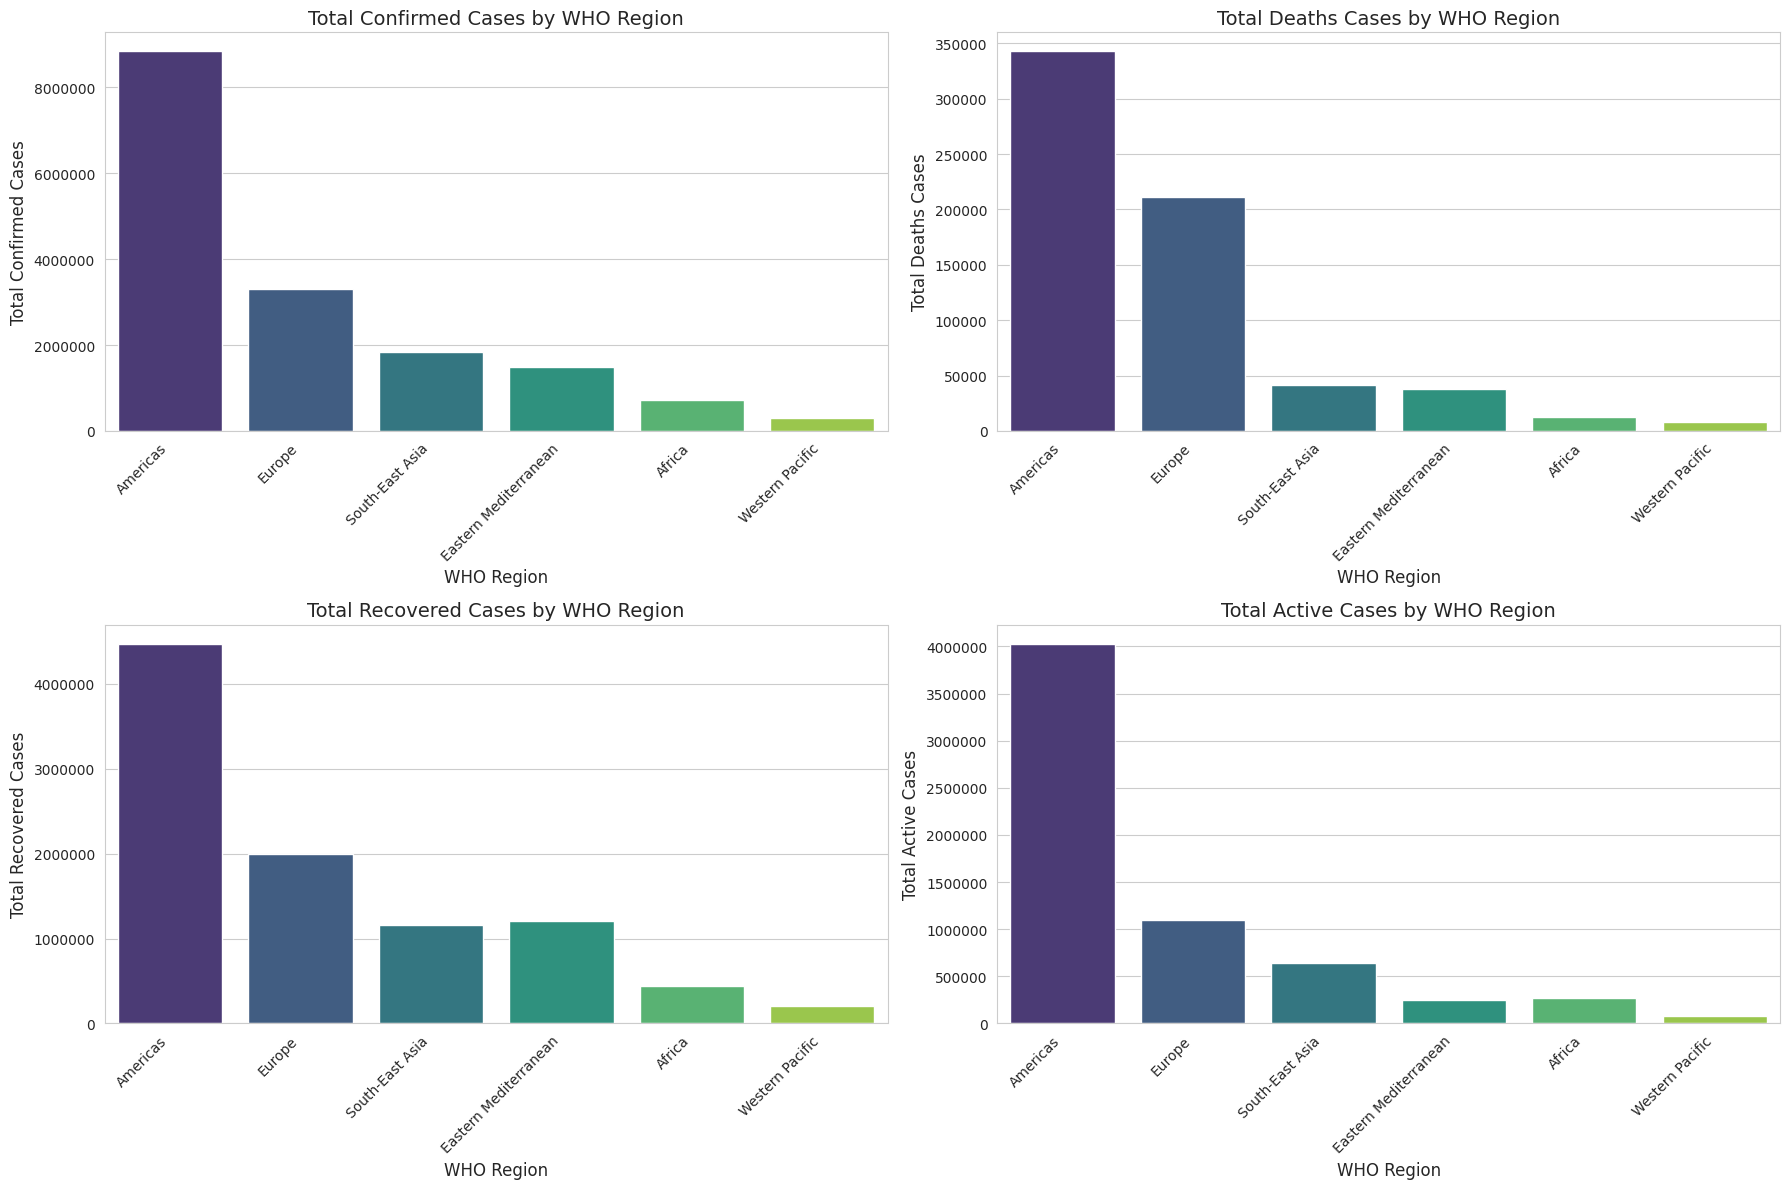

Bar plots for total 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases by WHO Region have been generated.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cases_columns = ['Confirmed', 'Deaths', 'Recovered', 'Active']

# Create a figure and a set of subplots for the bar plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

# Loop through each case type and create a bar plot
for i, col in enumerate(cases_columns):
    # Fix FutureWarning: Pass x to hue and set legend=False
    sns.barplot(x=regional_cases.index, y=regional_cases[col], ax=axes[i], hue=regional_cases.index, legend=False, palette='viridis')
    axes[i].set_title(f'Total {col} Cases by WHO Region', fontsize=14)
    axes[i].set_xlabel('WHO Region', fontsize=12)
    axes[i].set_ylabel(f'Total {col} Cases', fontsize=12)
    axes[i].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
    # Fix UserWarning: set_ticklabels() should only be used with a fixed number of ticks
    # Ensure ticks are set before labels, or let seaborn handle it and then adjust labels
    axes[i].set_xticks(range(len(regional_cases.index)))
    axes[i].set_xticklabels(regional_cases.index, rotation=45, ha='right') # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()

print("Bar plots for total 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases by WHO Region have been generated.")

## Top Countries for Confirmed, Recovered, and Active Cases

### Subtask:
Identify and visualize the top 10 countries with the highest 'Confirmed', 'Recovered', and 'Active' cases using bar plots. This extends the previous analysis on deaths to other critical metrics.


**Reasoning**:
To identify and visualize the top 10 countries for 'Confirmed', 'Recovered', and 'Active' cases, I will iterate through these metrics, group the DataFrame by 'Country/Region' to sum the respective values, sort them in descending order, and then create a bar plot for the top 10 for each metric. Subplots will be used to display all three visualizations in an organized manner.



/tmp/ipykernel_770/3058107995.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries_metric.index, y=top_10_countries_metric.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_770/3058107995.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(top_10_countries_metric.index, rotation=45, ha='right')
/tmp/ipykernel_770/3058107995.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries_metric.index, y=top_10_countries_metric.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_770/3058107995.py:13: UserWarning: set_ticklabels() should only be used with

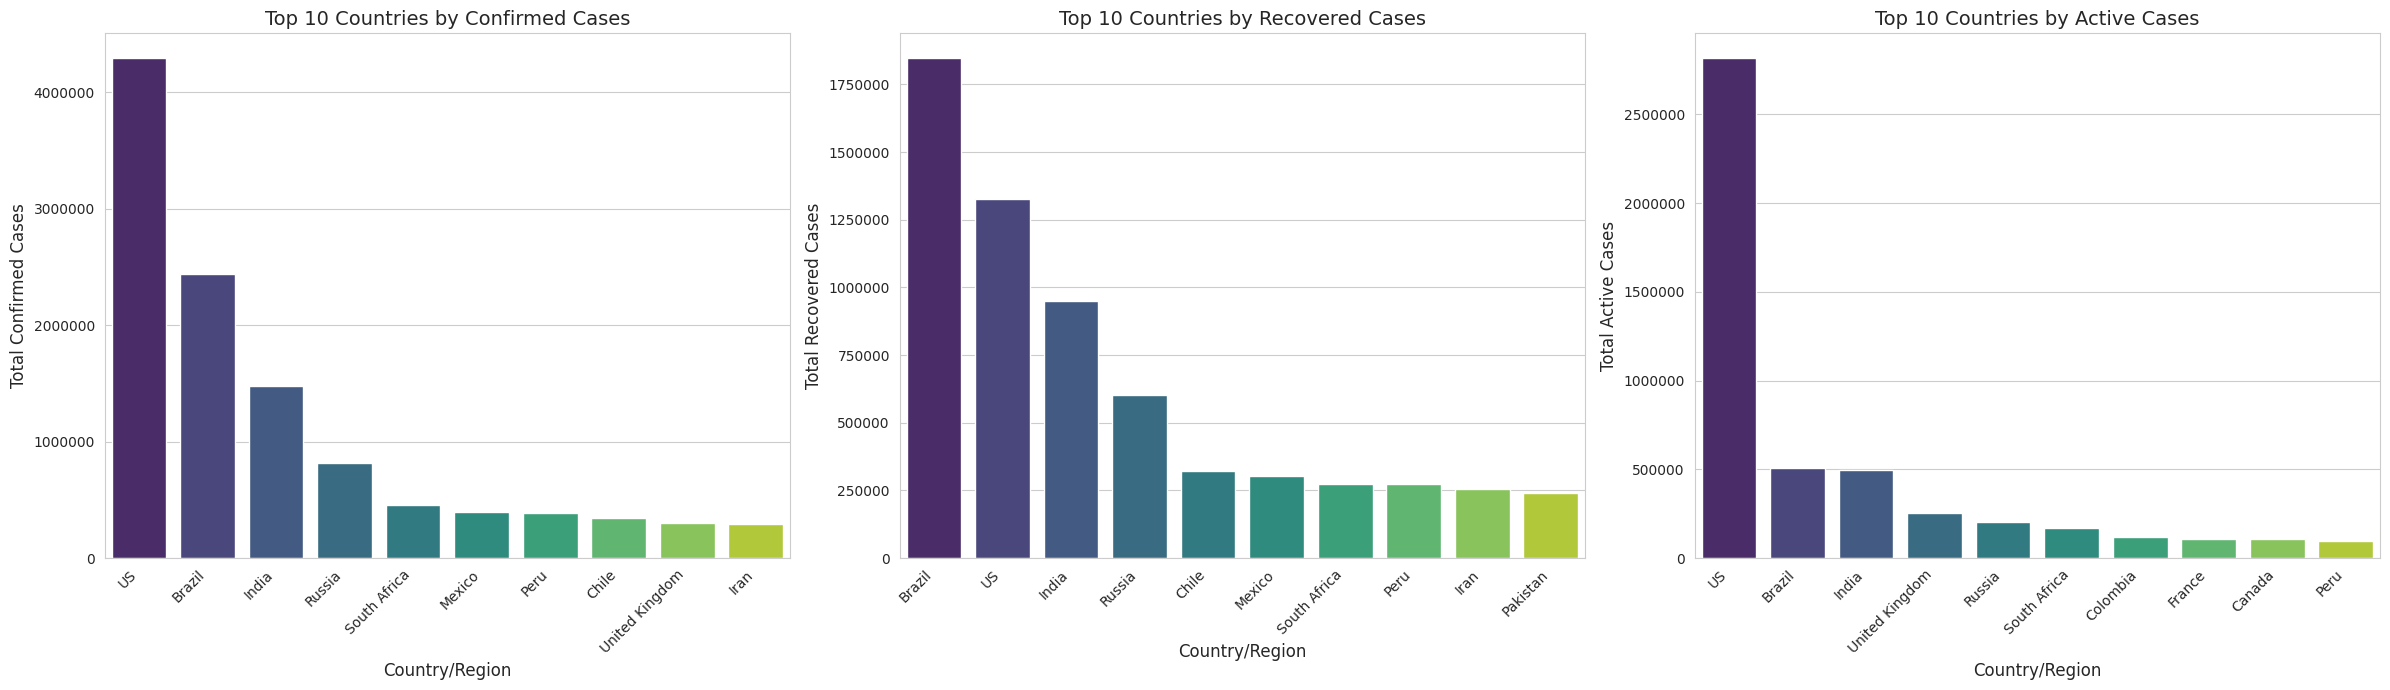

Bar plots for top 10 countries by Confirmed, Recovered, and Active cases have been generated.


In [15]:
metrics_to_plot = ['Confirmed', 'Recovered', 'Active']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    top_10_countries_metric = df.groupby('Country/Region')[metric].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top_10_countries_metric.index, y=top_10_countries_metric.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 10 Countries by {metric} Cases', fontsize=14)
    axes[i].set_xlabel('Country/Region', fontsize=12)
    axes[i].set_ylabel(f'Total {metric} Cases', fontsize=12)
    axes[i].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
    axes[i].set_xticklabels(top_10_countries_metric.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Bar plots for top 10 countries by Confirmed, Recovered, and Active cases have been generated.")

**Reasoning**:
The previous code generated `FutureWarning` and `UserWarning`. To address the `FutureWarning`, I will assign the `x` variable to `hue` and set `legend=False` in `sns.barplot`. For the `UserWarning`, I will explicitly set `xticks` before `set_xticklabels` to ensure compatibility.



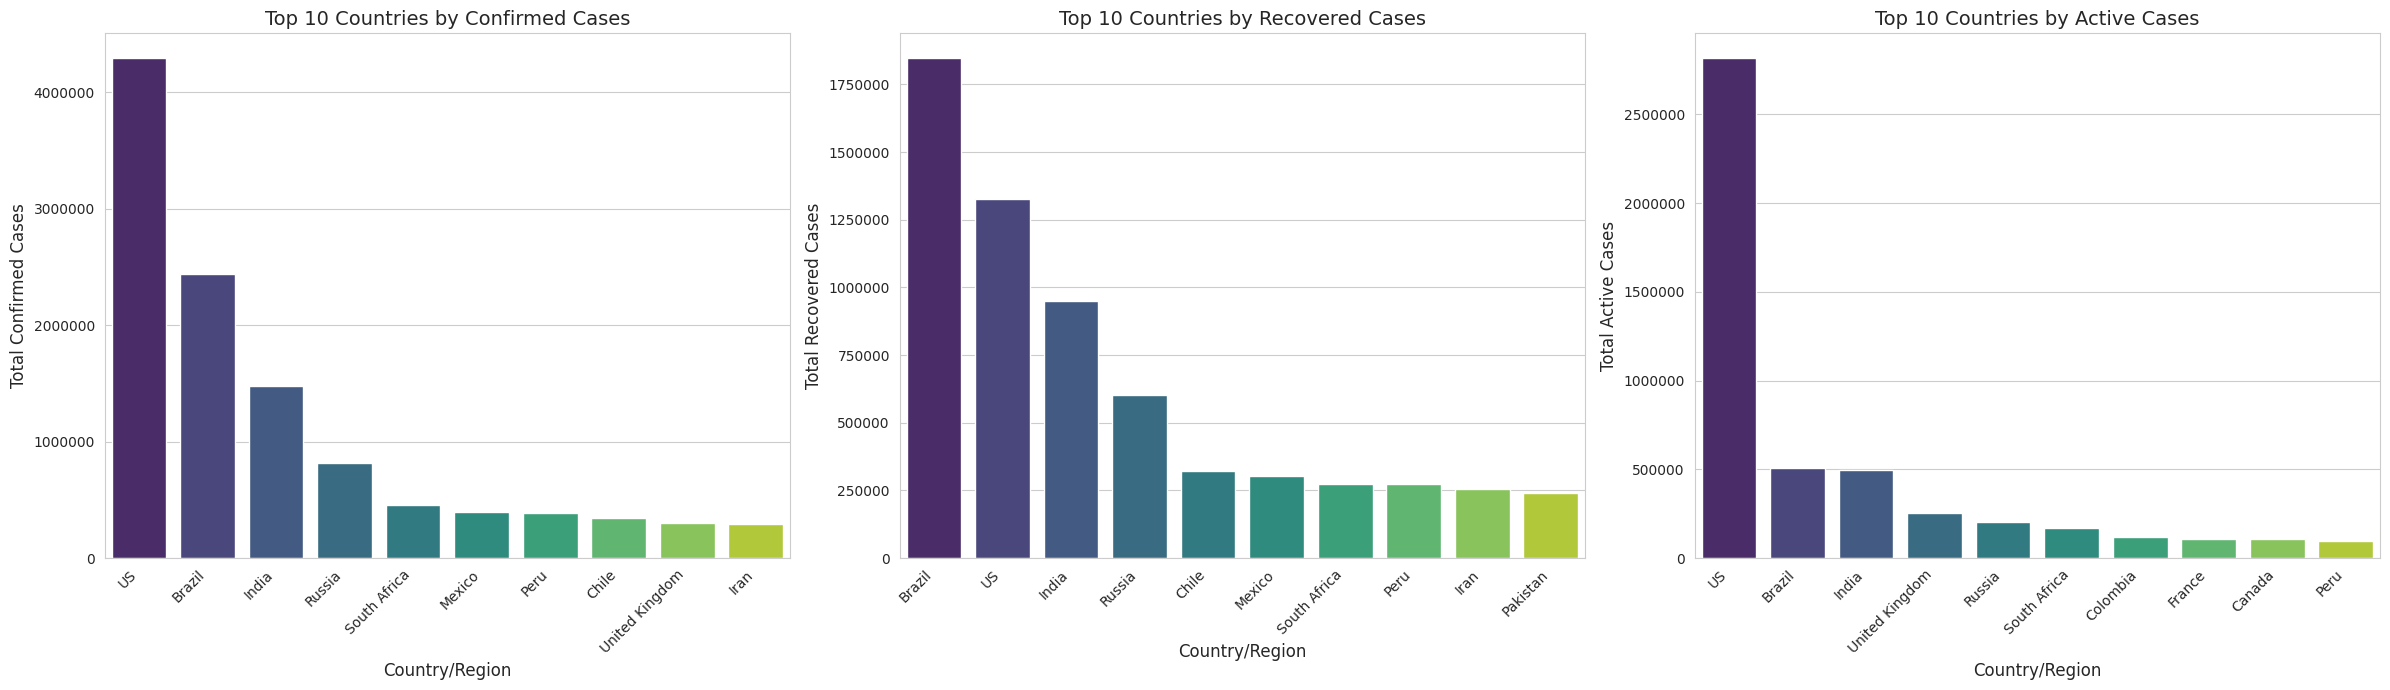

Bar plots for top 10 countries by Confirmed, Recovered, and Active cases have been generated.


In [16]:
metrics_to_plot = ['Confirmed', 'Recovered', 'Active']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    top_10_countries_metric = df.groupby('Country/Region')[metric].sum().sort_values(ascending=False).head(10)
    # Fix FutureWarning: Pass x to hue and set legend=False
    sns.barplot(x=top_10_countries_metric.index, y=top_10_countries_metric.values, ax=axes[i], hue=top_10_countries_metric.index, legend=False, palette='viridis')
    axes[i].set_title(f'Top 10 Countries by {metric} Cases', fontsize=14)
    axes[i].set_xlabel('Country/Region', fontsize=12)
    axes[i].set_ylabel(f'Total {metric} Cases', fontsize=12)
    axes[i].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
    # Fix UserWarning: set_ticklabels() should only be used with a fixed number of ticks
    axes[i].set_xticks(range(len(top_10_countries_metric.index)))
    axes[i].set_xticklabels(top_10_countries_metric.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Bar plots for top 10 countries by Confirmed, Recovered, and Active cases have been generated.")

## Analysis of Weekly Change

### Subtask:
Examine the '1 week change' and '1 week % increase' columns to understand recent trends in case numbers. This could involve identifying countries with the largest increases or decreases.


**Reasoning**:
To analyze recent trends, I will identify the top 10 countries with the largest '1 week change' and '1 week % increase' in cases, and then display these countries. This directly addresses the first and third instructions of the subtask.



In [17]:
import pandas as pd

# Identify top 10 countries by '1 week change'
top_10_change = df.sort_values(by='1 week change', ascending=False).head(10)
print("Top 10 Countries by '1 week change' (increase in cases):")
print(top_10_change[['Country/Region', '1 week change']])

print("\n" + "-" * 50 + "\n")

# Identify top 10 countries by '1 week % increase'
top_10_percent_increase = df.sort_values(by='1 week % increase', ascending=False).head(10)
print("Top 10 Countries by '1 week % increase':")
print(top_10_percent_increase[['Country/Region', '1 week % increase']])

Top 10 Countries by '1 week change' (increase in cases):
    Country/Region  1 week change
173             US         455582
79           India         324735
23          Brazil         323729
154   South Africa          78901
37        Colombia          53096
111         Mexico          46093
138         Russia          40468
6        Argentina          36642
132           Peru          32036
13      Bangladesh          18772

--------------------------------------------------

Top 10 Countries by '1 week % increase':
       Country/Region  1 week % increase
130  Papua New Guinea             226.32
63             Gambia             191.07
11            Bahamas             119.54
186          Zimbabwe              57.85
99              Libya              42.78
58           Ethiopia              42.52
22           Botswana              41.57
97            Lesotho              40.67
160          Suriname              37.44
41         Costa Rica              37.34


**Reasoning**:
To visualize the top 10 countries by '1 week change' and '1 week % increase', I will create two bar plots using the previously identified `top_10_change` and `top_10_percent_increase` dataframes. This addresses the remaining instructions in the subtask.



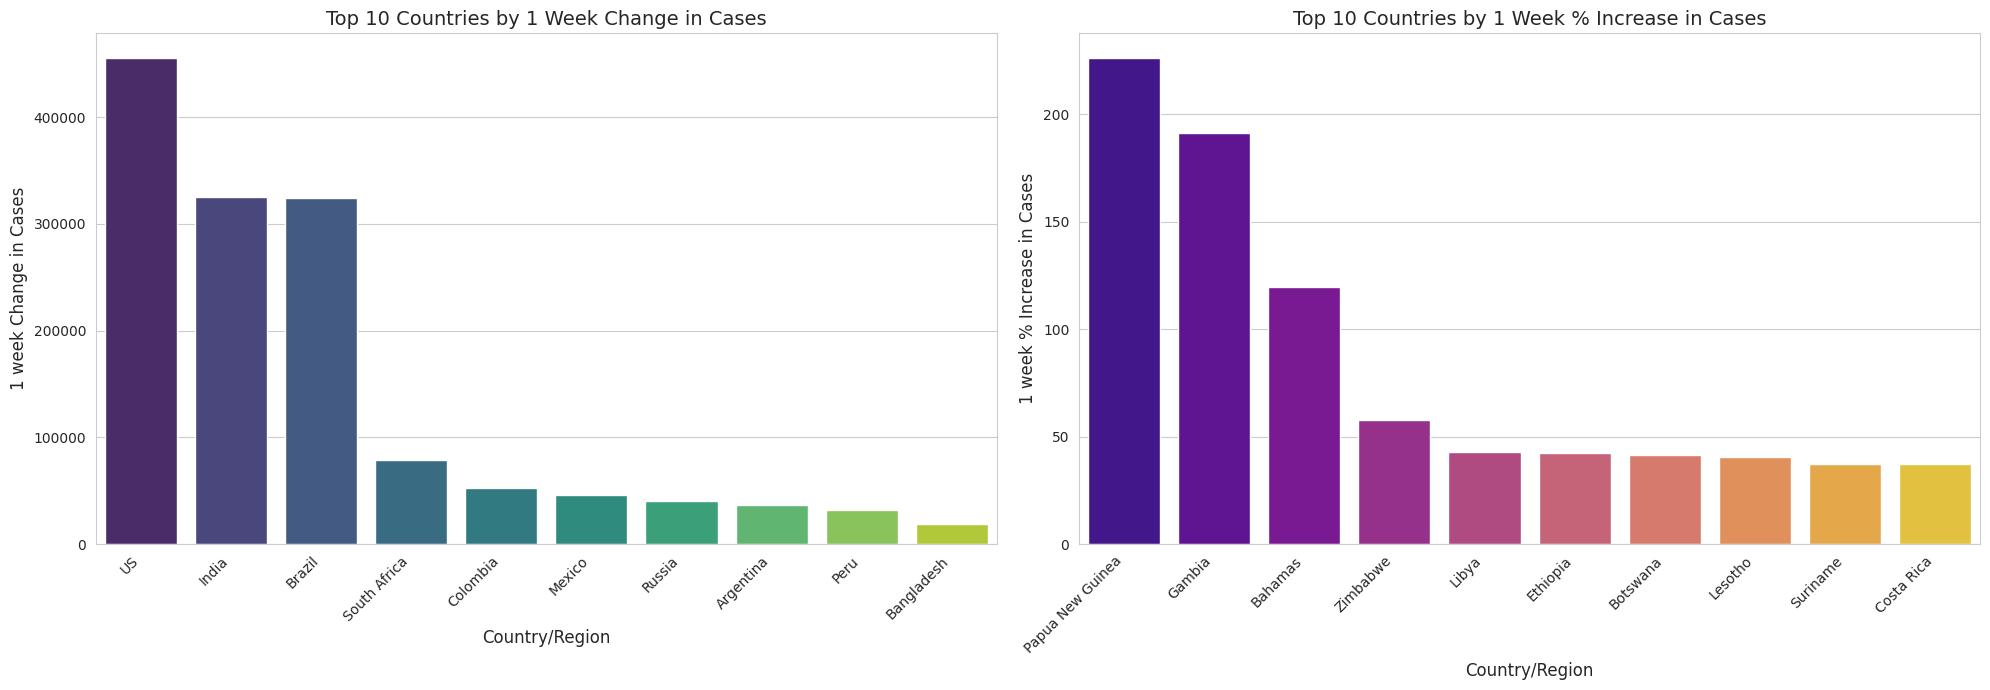

Bar plots for '1 week change' and '1 week % increase' have been generated.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots for the two visualizations
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for '1 week change'
sns.barplot(x=top_10_change['Country/Region'], y=top_10_change['1 week change'], ax=axes[0], palette='viridis', hue=top_10_change['Country/Region'], legend=False)
axes[0].set_title('Top 10 Countries by 1 Week Change in Cases', fontsize=14)
axes[0].set_xlabel('Country/Region', fontsize=12)
axes[0].set_ylabel('1 week Change in Cases', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
axes[0].set_xticks(range(len(top_10_change['Country/Region'])))
axes[0].set_xticklabels(top_10_change['Country/Region'], rotation=45, ha='right')

# Plot for '1 week % increase'
sns.barplot(x=top_10_percent_increase['Country/Region'], y=top_10_percent_increase['1 week % increase'], ax=axes[1], palette='plasma', hue=top_10_percent_increase['Country/Region'], legend=False)
axes[1].set_title('Top 10 Countries by 1 Week % Increase in Cases', fontsize=14)
axes[1].set_xlabel('Country/Region', fontsize=12)
axes[1].set_ylabel('1 week % Increase in Cases', fontsize=12)
axes[1].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
axes[1].set_xticks(range(len(top_10_percent_increase['Country/Region'])))
axes[1].set_xticklabels(top_10_percent_increase['Country/Region'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Bar plots for '1 week change' and '1 week % increase' have been generated.")

## Rate-Based Analysis

### Subtask:
Analyze and visualize the 'Deaths / 100 Cases' and 'Recovered / 100 Cases' to understand the fatality and recovery rates across different countries or regions.


**Reasoning**:
To understand the basic statistical properties of 'Deaths / 100 Cases' and 'Recovered / 100 Cases', I will calculate and display their descriptive statistics, including mean, median, standard deviation, min, and max values.



In [19]:
print("Descriptive statistics for 'Deaths / 100 Cases':")
print(df['Deaths / 100 Cases'].describe())
print("\nDescriptive statistics for 'Recovered / 100 Cases':")
print(df['Recovered / 100 Cases'].describe())

Descriptive statistics for 'Deaths / 100 Cases':
count    187.000000
mean       3.019519
std        3.454302
min        0.000000
25%        0.945000
50%        2.150000
75%        3.875000
max       28.560000
Name: Deaths / 100 Cases, dtype: float64

Descriptive statistics for 'Recovered / 100 Cases':
count    187.000000
mean      64.820535
std       26.287694
min        0.000000
25%       48.770000
50%       71.320000
75%       86.885000
max      100.000000
Name: Recovered / 100 Cases, dtype: float64


**Reasoning**:
To visualize the distributions of 'Deaths / 100 Cases' and 'Recovered / 100 Cases', I will create histograms for each, which directly addresses the second instruction of the subtask.



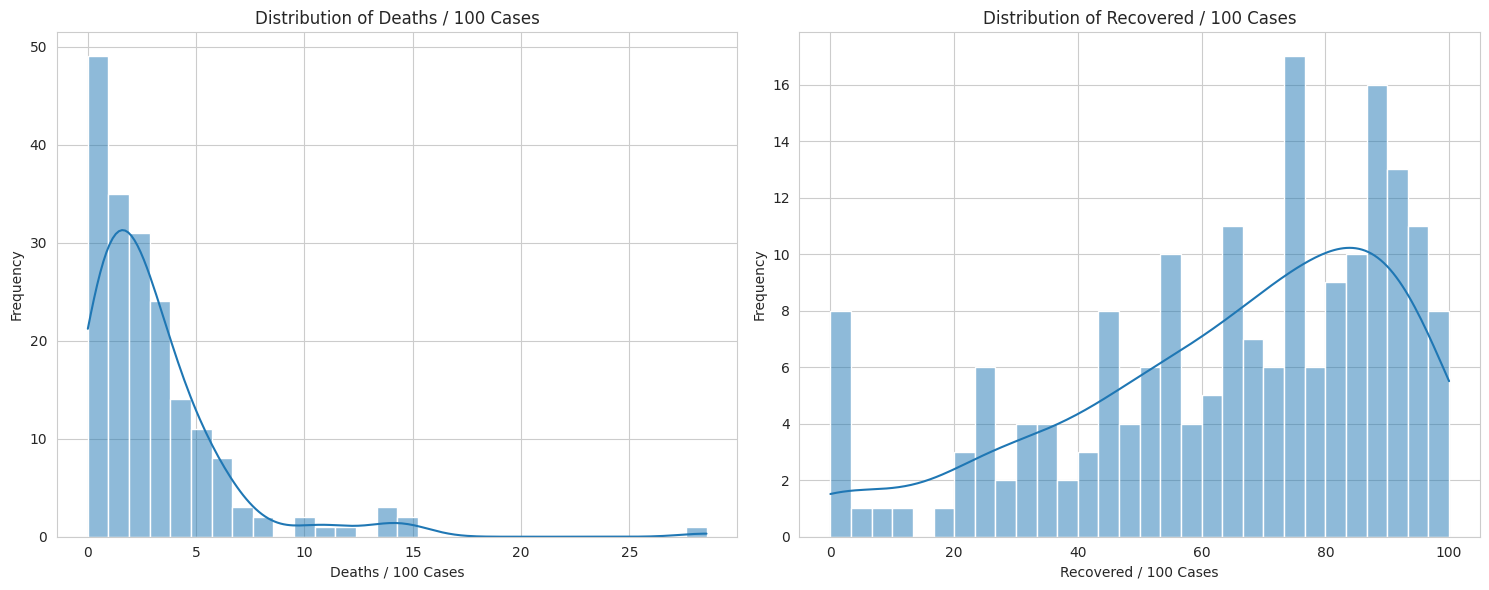

Histograms for 'Deaths / 100 Cases' and 'Recovered / 100 Cases' have been generated.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Deaths / 100 Cases'], bins=30, kde=True)
plt.title('Distribution of Deaths / 100 Cases')
plt.xlabel('Deaths / 100 Cases')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Recovered / 100 Cases'], bins=30, kde=True)
plt.title('Distribution of Recovered / 100 Cases')
plt.xlabel('Recovered / 100 Cases')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Histograms for 'Deaths / 100 Cases' and 'Recovered / 100 Cases' have been generated.")

**Reasoning**:
To identify the top 10 countries with the highest and lowest 'Deaths / 100 Cases' and 'Recovered / 100 Cases', I will sort the DataFrame by these columns and select the top and bottom 10 entries for each metric.



In [21]:
print("\nTop 10 Countries by Highest 'Deaths / 100 Cases':")
print(df.sort_values(by='Deaths / 100 Cases', ascending=False).head(10)[['Country/Region', 'Deaths / 100 Cases']])

print("\nTop 10 Countries by Lowest 'Deaths / 100 Cases':")
print(df.sort_values(by='Deaths / 100 Cases', ascending=True).head(10)[['Country/Region', 'Deaths / 100 Cases']])

print("\nTop 10 Countries by Highest 'Recovered / 100 Cases':")
print(df.sort_values(by='Recovered / 100 Cases', ascending=False).head(10)[['Country/Region', 'Recovered / 100 Cases']])

print("\nTop 10 Countries by Lowest 'Recovered / 100 Cases':")
print(df.sort_values(by='Recovered / 100 Cases', ascending=True).head(10)[['Country/Region', 'Recovered / 100 Cases']])


Top 10 Countries by Highest 'Deaths / 100 Cases':
     Country/Region  Deaths / 100 Cases
184           Yemen               28.56
177  United Kingdom               15.19
16          Belgium               14.79
85            Italy               14.26
61           France               13.71
77          Hungary               13.40
120     Netherlands               11.53
111          Mexico               11.13
157           Spain               10.44
183  Western Sahara               10.00

Top 10 Countries by Lowest 'Deaths / 100 Cases':
    Country/Region  Deaths / 100 Cases
30        Cambodia                 0.0
19          Bhutan                 0.0
59            Fiji                 0.0
55         Eritrea                 0.0
49        Dominica                 0.0
75        Holy See                 0.0
68       Greenland                 0.0
69         Grenada                 0.0
94            Laos                 0.0
114       Mongolia                 0.0

Top 10 Countries by Highest '

## Final Task

### Subtask:
Summarize all the findings from the comprehensive analysis, highlighting key insights and patterns observed in the dataset.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 187 entries and 15 columns with no missing values, including metrics like 'Confirmed', 'Deaths', 'Recovered', 'Active' cases, and derived rates. The average number of deaths across countries is approximately 3497.52.
*   Distributions of 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases are highly skewed towards lower values, with a few outliers showing very high case counts. Logarithmic scales were necessary to visualize these distributions effectively.
*   A strong positive correlation was observed among 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases, indicating that as one metric increases, the others tend to increase as well.
*   **Regional Impact**: The Americas region consistently shows the highest total numbers across 'Confirmed', 'Deaths', 'Recovered', and 'Active' cases compared to other WHO regions.
*   **Top Countries by Case Count**:
    *   Countries like the USA, Brazil, and India frequently appear among the top 10 for 'Confirmed', 'Recovered', and 'Active' cases, indicating a high overall burden.
*   **Weekly Trends**:
    *   **Absolute '1 week change'**: Countries with large existing caseloads, such as the US (455,582 cases), India (324,735 cases), and Brazil (323,729 cases), experienced the highest absolute increases in cases.
    *   **'1 week % increase'**: Smaller nations or those with lower initial baselines, like Papua New Guinea (226.32%), Gambia (191.07%), and Bahamas (119.54%), exhibited the highest percentage increases, signaling rapidly emerging or accelerating outbreaks.
*   **Rate-Based Analysis**:
    *   **'Deaths / 100 Cases'**: The death rate per 100 cases varied significantly (mean $\approx$ 3.02%, max $\approx$ 28.56%). Yemen showed an exceptionally high death rate of 28.56%, while several countries reported 0%.
    *   **'Recovered / 100 Cases'**: Recovery rates also showed wide variation (mean $\approx$ 64.82%, ranging from 0% to 100%). Countries like Dominica, Holy See, and Grenada reported 100% recovery, while others like Canada, Mozambique, and the UK showed very low reported recovery rates (0-0.48%).

### Insights or Next Steps

*   The disparity between absolute and percentage weekly increases highlights the need for nuanced interpretation of trends; absolute numbers indicate overall strain on healthcare, while percentages can point to rapidly escalating situations in regions that might have been less affected previously.
*   The wide variations in 'Deaths / 100 Cases' and 'Recovered / 100 Cases' rates suggest that further investigation into country-specific healthcare infrastructure, testing capacities, reporting methodologies, and demographic factors is warranted to understand these differences better.
